# Final Assignment - Canada Housing Prices Analysis
### Group 14
#### Ei Htoo Khaing, Lio, James Nguyen
In this assignment, we will self-answer qeustions about Canadian real estate price trends and investigates how they are influenced by key socioeconomic factors.  
The dataset is retrieved from github [https://github.com/tahczeban/CANADIAN_REAL_ESTATE_PRICES].

We understand that, when submitting this assingment, we are abiding to Seneca's standards of academic honesty.

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
                    .getOrCreate()

### 1: Data Cleaning and Preparation (Filtering)

First, open the files and set the variables. Clean the unnecessary columns or change columns. Filter only the needed year values.

In [2]:
from pyspark.sql.functions import col

house_df = spark.read.csv('/data/avg_house_price.csv', header=True, inferSchema=True)
pop_df = spark.read.csv('/data/population_analysis_sid.csv', header=True, inferSchema=True)
income_df = spark.read.csv('/data/prov_hh_income.csv', header=True, inferSchema=True)

# Remove null values if there's any, then filter out only the years needed to analyse
house_df = house_df.dropna().filter(col('Year') != 2021)
pop_df = pop_df.dropna().filter(col("Year") >= 2015).filter(col("Year") != 2021)
income_df = income_df.dropna().filter(col("Year") >= 2015)

In [3]:
income_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+------+
|Year|Province|Income|
+----+--------+------+
|2015| Alberta|108594|
|2015|      BC| 79234|
|2015|      MB| 72971|
|2015|      NB| 63767|
|2015|      NL| 75183|
|2015|      NS| 64717|
|2015|      NU|110546|
|2015|     NWT|116295|
|2015|     ONT| 79674|
|2015|     PEI| 63660|
|2015|      QC| 61161|
|2015|      SK| 83814|
|2015|      YK| 96529|
+----+--------+------+



In [4]:
pop_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+----------+
|Year|Province|Population|
+----+--------+----------+
|2015|      AB|  16548357|
|2015|      BC|  19082570|
|2015|      MB|   5164103|
|2015|      NB|   3037185|
|2015|      NL|   2113237|
|2015|      NS|   3749412|
|2015|      NU|    145593|
|2015|     NWT|    176998|
|2015|     ONT|  54792403|
|2015|     PEI|    578067|
|2015|      QC|  32691481|
|2015|      SK|   4482873|
|2015|      YK|    149981|
+----+--------+----------+



In [5]:
house_df.filter(col('Year') == 2015).orderBy("Province").show()

+----+--------+---------+
|Year|Province|Avg_price|
+----+--------+---------+
|2015|      AB|   432800|
|2015|      BC|   610000|
|2015|      MB|   283000|
|2015|      NB|   199800|
|2015|      NL|   299300|
|2015|      NS|   256100|
|2015|     ONT|   455000|
|2015|     PEI|   204200|
|2015|      QC|   305800|
|2015|      SK|   332600|
+----+--------+---------+



### 2: Create a new column with the same Format for Province (When/Otherwise operations)

In [ ]:
# After checking the housing dataset, only 10 provinces' housing data are recorded. Therefore, I'll filter the "NU, NWT, YK" data from pop_df and income_df
# First, change alberta to AB
from pyspark.sql.functions import when, col

income_df = income_df.withColumn("Province",
    when(col("Province") == "Alberta", "AB")
    .otherwise(col("Province"))
)

#Filter the provinces needed
provinces = ["AB","BC","MB","NB","NL","NS","ONT","PEI","QC", "SK"]

pop_df = pop_df.filter(col("Province").isin(provinces))
income_df = income_df.filter(col("Province").isin(provinces))
pop_df.count()
income_df.count()
house_df.count()


60

### 3: Joining Datasets (Joining and/or unions of dataframes)
 
After preparation, we'll combine all three datasets using join.

In [16]:
# Join datasets
combined_df = house_df \
    .join(pop_df, on = ["Year", "Province"], how = "inner") \
    .join(income_df, on = ["Year", "Province"], how = "inner")

combined_df.show()

+----+--------+---------+----------+------+
|Year|Province|Avg_price|Population|Income|
+----+--------+---------+----------+------+
|2015|      BC|   610000|  19082570| 79234|
|2016|      BC|   717600|  19386872| 79996|
|2017|      BC|   775400|  19681992| 83217|
|2018|      BC|   816300|  20001433| 82730|
|2019|      BC|   785500|  20339311| 87208|
|2020|      BC|   848200|  20603068| 97537|
|2015|      MB|   283000|   5164103| 72971|
|2016|      MB|   288800|   5244283| 72772|
|2017|      MB|   297400|   5327896| 75835|
|2018|      MB|   300000|   5402266| 74748|
|2019|      MB|   305200|   5470522| 76033|
|2020|      MB|   314400|   5518408| 82483|
|2015|      NB|   199800|   3037185| 63767|
|2016|      NB|   207800|   3051063| 65074|
|2017|      NB|   208200|   3063986| 66506|
|2018|      NB|   214800|   3079425| 67152|
|2019|      NB|   218100|   3104622| 68325|
|2020|      NB|   222700|   3129367| 73222|
|2015|      NL|   299300|   2113237| 75183|
|2016|      NL|   298800|   2117

### 4: GroupBy and Aggregation (Grouping & Aggregating (groupBy))

Then, Group the data by Year and find the average.

In [22]:
from pyspark.sql.functions import avg,round

price_by_year = combined_df.groupBy("Year")\
    .agg(round(avg("Avg_price"),3).alias("Avg_House_Price"))\
        .orderBy("Year")

price_by_year.show()

+----+---------------+
|Year|Avg_House_Price|
+----+---------------+
|2015|     327311.111|
|2016|     350377.778|
|2017|     371833.333|
|2018|     381355.556|
|2019|     383711.111|
|2020|     411011.111|
+----+---------------+



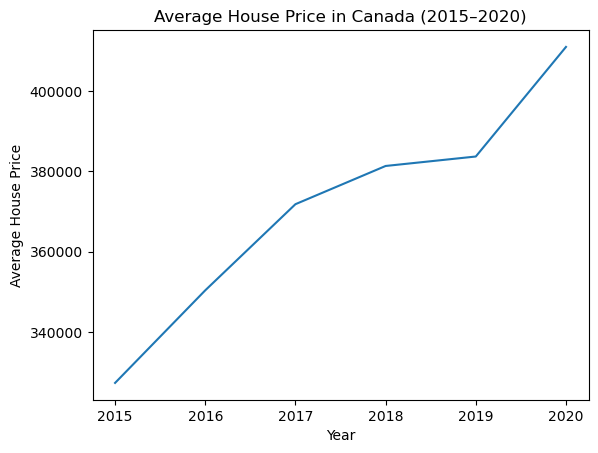

In [ ]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
price_pd = price_by_year.toPandas()

plt.figure()
plt.plot(price_pd["Year"], price_pd["Avg_House_Price"])
plt.xlabel("Year")
plt.ylabel("Average House Price")
plt.title("Average House Price in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [23]:
income_by_year = combined_df.groupBy("Year")\
    .agg(round(avg("Income"),3).alias("Avg_Income"))\
        .orderBy("Year")
income_by_year.show()

+----+----------+
|Year|Avg_Income|
+----+----------+
|2015| 71575.667|
|2016| 71566.556|
|2017| 73630.778|
|2018|   73863.0|
|2019| 75703.556|
|2020| 82091.333|
+----+----------+



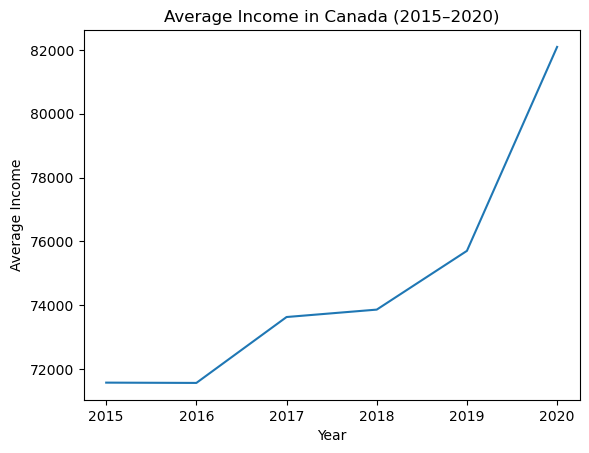

In [41]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
income_pd = income_by_year.toPandas()

plt.figure()
plt.plot(income_pd["Year"], income_pd["Avg_Income"])
plt.xlabel("Year")
plt.ylabel("Average Income")
plt.title("Average Income in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [45]:
from pyspark.sql.functions import avg, round, col

pop_by_year = combined_df.groupBy("Year")\
    .agg(round(avg(col("Population")/1000000), 3).alias("Avg_Population_Millions"))\
    .orderBy("Year")

pop_by_year.show()

+----+-----------------------+
|Year|Avg_Population_Millions|
+----+-----------------------+
|2015|                 13.966|
|2016|                 14.108|
|2017|                 14.283|
|2018|                 14.484|
|2019|                 14.693|
|2020|                 14.868|
+----+-----------------------+



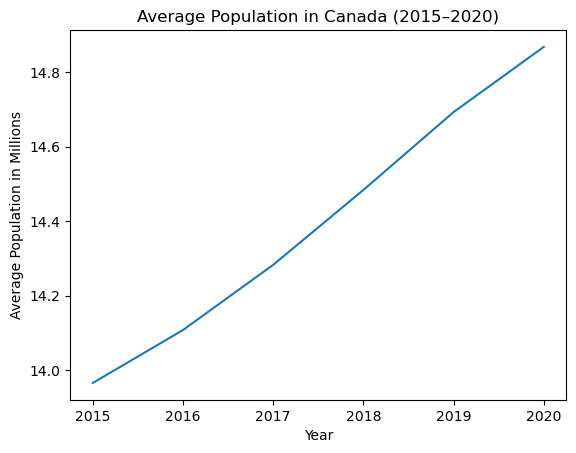

In [46]:
import matplotlib.pyplot as plt

# Convert to pandas
# Need to convert to pandas because PySpark distributes data as clusters across machines for processing 
pop_pd = pop_by_year.toPandas()

plt.figure()
plt.plot(pop_pd["Year"], pop_pd["Avg_Population_Millions"])
plt.xlabel("Year")
plt.ylabel("Average Population in Millions")
plt.title("Average Population in Canada (2015–2020)")
plt.xticks(price_pd["Year"]) 
plt.show()

In [47]:
# Join datasets
combined_avg_df = price_by_year \
    .join(pop_by_year, on = "Year", how = "inner") \
    .join(income_by_year, on = "Year", how = "inner")\
    .orderBy("Year")

combined_avg_df.show()

+----+---------------+-----------------------+----------+
|Year|Avg_House_Price|Avg_Population_Millions|Avg_Income|
+----+---------------+-----------------------+----------+
|2015|     327311.111|                 13.966| 71575.667|
|2016|     350377.778|                 14.108| 71566.556|
|2017|     371833.333|                 14.283| 73630.778|
|2018|     381355.556|                 14.484|   73863.0|
|2019|     383711.111|                 14.693| 75703.556|
|2020|     411011.111|                 14.868| 82091.333|
+----+---------------+-----------------------+----------+



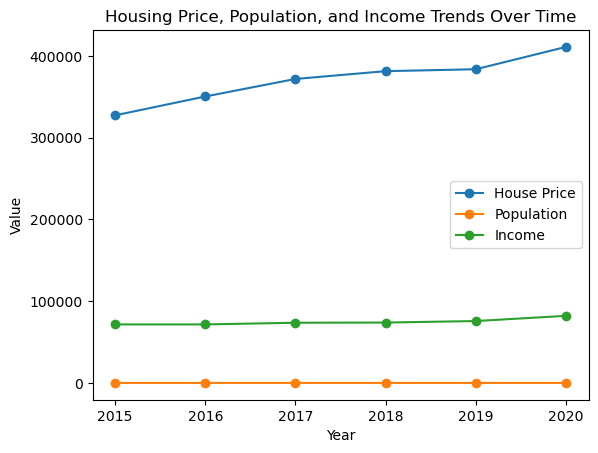

In [55]:
combined_pd = combined_avg_df.toPandas()

plt.figure()
plt.plot(combined_pd["Year"], combined_pd["Avg_House_Price"], marker='o', label="House Price")
plt.plot(combined_pd["Year"], combined_pd["Avg_Population_Millions"], marker='o', label="Population")
plt.plot(combined_pd["Year"], combined_pd["Avg_Income"], marker='o', label="Income")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Housing Price, Population, and Income Trends Over Time")
plt.xticks(combined_pd["Year"])
plt.legend()

plt.show()